In [52]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
import matplotlib.pyplot as plt
import sys
import tifffile as tf
import numpy as np
sys.path.append("..")
from neurotrack.data.neuron_data import Dataset, DataLoader, DataGenerator, DrawingComplexityConfig

In [125]:
dataset_path = "/home/brysongray/neurotrack/training_dir"
dataset = Dataset(dataset_path)
dataset.get_complexity_distribution()

{'morphology_distribution': {'moderate': 648, 'complex': 1149, 'simple': 809},
 'complexity_stats': {'mean': 0.5855717574827322,
  'std': 0.3635426746844333,
  'min': 0.0,
  'max': 1.0}}

In [126]:
dataloader = DataLoader(dataset, complexity=1.0, morphology="any", stochastic_complexity=True)

Sampled image path: /home/brysongray/neurotrack/training_dir/uint8_ChaMARCM-F000096_seg001_subtree_04_image.tif
Sampled complexity: 1.0


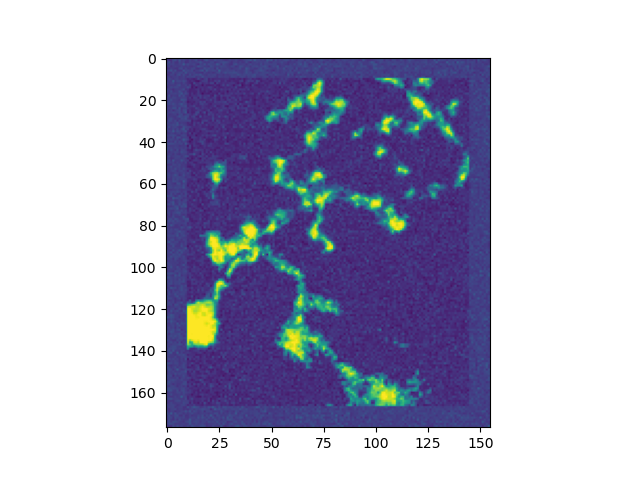

In [176]:
entry = dataloader.sample()
img_path = entry['img_path']
print(f"Sampled image path: {img_path}")
print(f"Sampled complexity: {entry['complexity']}")
img = tf.imread(img_path)

if img.dtype != np.float32:
    img = img.astype(np.float32) / img.max()

plt.close('all')
fig = plt.figure()
plt.imshow(img[0].max(axis=0), vmin=0, vmax=1)
plt.show()

In [28]:
morphology = "moderate"
complexity = 0.0
dataloader.set_morphology(morphology)
dataloader.set_complexity(complexity)

Sampled image path: /home/brysongray/neurotrack/neuromorpho_training_dir/Cha-F-000302.CNG_subtree_02_image.tif
Sampled complexity: 0.0


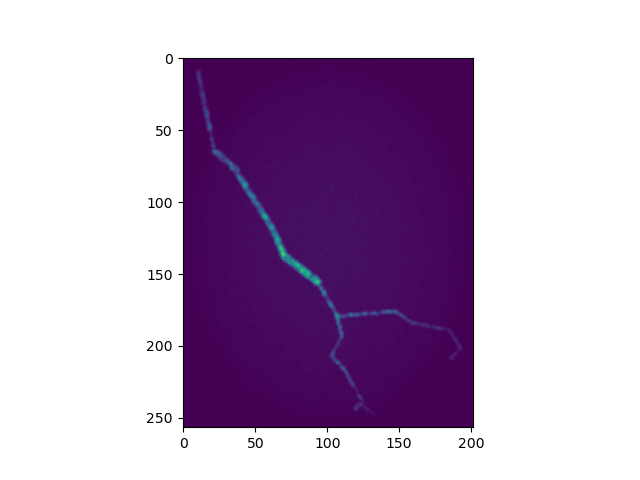

In [46]:
entry = dataloader.sample()
img_path = entry['img_path']
print(f"Sampled image path: {img_path}")
print(f"Sampled complexity: {entry['complexity']}")
img = tf.imread(img_path)

if img.dtype != np.float32:
    img = img.astype(np.float32) / img.max()

plt.close('all')
fig = plt.figure()
plt.imshow(img[0].max(axis=0), vmin=0, vmax=1)
plt.show()

In [ ]:
rng = np.random.default_rng(seed=0)
complexity_config = DrawingComplexityConfig()
cache_dir = "/home/brysongray/neurotrack/training_data"
generator = DataGenerator(cache_dir=cache_dir, complexity_config=complexity_config, rng=rng)

In [50]:
subtrees_per_swc = 1
complexity_range = (0.0, 1.0)
swc_dir = "/home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset"
image_dir = None
dataset_size = 1
generator.generate_data(subtrees_per_swc=subtrees_per_swc, complexity_range=complexity_range, swc_dir=swc_dir, img_dir=image_dir, dataset_size=dataset_size)

Processing 6 SWC files...
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/091201c1.swc
Processed 091201c1: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/091204c2.swc
Processed 091204c2: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/080926a.swc
Processed 080926a: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/091202c2.swc
Processed 091202c2: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/091226c2.swc
Processed 091226c2: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/100108c3.swc
Processed 100108c3: 1 subtrees generated
Entry data saved to: /home/brysongray/neurotrack/test_data/generated_data_entries.csv

Processing co

{'processed_files': 6,
 'total_subtrees': 36,
 'output_dir': '/home/brysongray/neurotrack/test_data'}